In [1]:
!pip install transformers datasets seqeval accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=ebffc40fe101e5a61ab2443bd5668362e100fad858a7b8f452b15d32be3e3d24
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


# **1 - Persiapan Dataset**
* Mengambil dataset dari gdrive
* Parsing dataset dengan kolom `Sentence #` sebagai pemisah
* Melabeli data dengan `label2id`
* Split dataset menjadi `train`, `val`, dan `test`

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

path = "/content/drive/MyDrive/Tugas Akhir/"
os.listdir(path)

['WebScraping.ipynb',
 'NERSkill.Id.txt',
 'nerskill_parsed.json',
 'train.json',
 'tokenized_dataset',
 'val.json',
 'test.json',
 'experiment_results.csv',
 'NER.ipynb']

In [4]:
dataset_path = "/content/drive/MyDrive/Tugas Akhir/NERSkill.Id.txt"

with open(dataset_path, "r", encoding="utf-8") as f:
    for i in range(30):
        print(f.readline().strip())

Sentence #	Word	Tag
sentence 411	Pendidikan	O
minimal	O
S1	O
dari	O
Jurusan	O
Teknik	O
Informatika	O
,	O
Ilmu	O
Komputer	O
,	O
Sistem	O
Informasi	O
.	O
Memahami	O
konsep	O
dasar	O
pemrograman	B-HSkill
.	O
Menguasai	O
pembuatan	O
web-based	B-HSkill
application	I-HSkill
dengan	O
Javascript	B-Tech
,	O
CSS3	B-Tech
.	O
Menguasai	O


In [118]:
from collections import Counter

label_counter = Counter()

with open(dataset_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        if not line:
            continue

        # Pisahkan berdasarkan spasi apa pun (bukan hanya tab)
        parts = line.split()

        # Skip baris 'sentence 411', 'sentence 5', dst.
        if parts[0].lower() == "sentence":
            continue

        # Format valid minimal: [token, label] atau [anything, token, label]
        if len(parts) < 2:
            continue

        # Label = kolom terakhir
        label = parts[-1]

        # Pastikan label valid (mengandung O atau B-/I-)
        if label in ["O"] or "-" in label:
            label_counter[label] += 1

# Tampilkan hasil lengkap
for label, count in label_counter.items():
    print(f"{label:10} : {count}")


O          : 349597
B-HSkill   : 17003
I-HSkill   : 11508
B-Tech     : 17296
I-Tech     : 4414
B-SSkill   : 10891
I-SSkill   : 3858


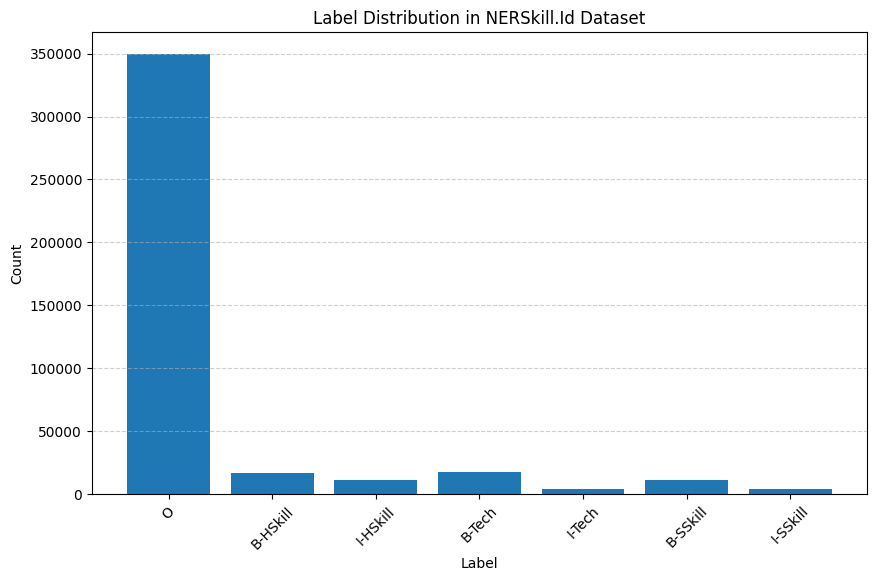

In [119]:
import matplotlib.pyplot as plt

# Data distribusi label yang sudah kamu hitung
label_counts = {
    "O": 349597,
    "B-HSkill": 17003,
    "I-HSkill": 11508,
    "B-Tech": 17296,
    "I-Tech": 4414,
    "B-SSkill": 10891,
    "I-SSkill": 3858
}

labels = list(label_counts.keys())
counts = list(label_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, counts)
plt.title("Label Distribution in NERSkill.Id Dataset")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [120]:
import plotly.graph_objects as go

# Data asli label count
label_counts = {
    "O": 349597,
    "B-HSkill": 17003,
    "I-HSkill": 11508,
    "B-Tech": 17296,
    "I-Tech": 4414,
    "B-SSkill": 10891,
    "I-SSkill": 3858
}

# Gabungkan B + I untuk tiap kategori
HSkill_total = label_counts["B-HSkill"] + label_counts["I-HSkill"]
Tech_total   = label_counts["B-Tech"] + label_counts["I-Tech"]
SSkill_total = label_counts["B-SSkill"] + label_counts["I-SSkill"]

# Untuk stacked bar: B dan I tetap dipisah, tetapi berada pada kategori yang sama
categories = ["HSkill", "Tech", "SSkill"]

b_values = [label_counts["B-HSkill"], label_counts["B-Tech"], label_counts["B-SSkill"]]
i_values = [label_counts["I-HSkill"], label_counts["I-Tech"], label_counts["I-SSkill"]]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=categories,
    y=b_values,
    name="B-Label",
    marker_color="#4CAF50"
))

fig.add_trace(go.Bar(
    x=categories,
    y=i_values,
    name="I-Label",
    marker_color="#FFC107"
))

fig.update_layout(
    barmode='stack',
    title="Stacked Label Distribution per Category (HSkill, Tech, SSkill)",
    xaxis_title="Category",
    yaxis_title="Count",
    template="plotly_white",
    width=900,
    height=500
)

fig.show()

In [5]:
sentences = []
current_tokens = []
current_labels = []

with open(dataset_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line == "":
            continue

        # Pisahkan kolom berdasarkan tab
        parts = line.split("\t")

        # Jika baris adalah "sentence X"
        if parts[0].startswith("sentence"):

            # Simpan kalimat sebelumnya bila ada
            if current_tokens:
                sentences.append({
                    "tokens": current_tokens,
                    "labels": current_labels
                })

            # Reset kalimat baru
            current_tokens = []
            current_labels = []

            # Format: sentence XXX <TAB> token <TAB> tag
            if len(parts) == 3:
                token = parts[1]
                tag = parts[2]
                current_tokens.append(token)
                current_labels.append(tag)

        else:
            # Format baris berikutnya: token <TAB> label
            if len(parts) == 2:
                token = parts[0]
                tag = parts[1]
                current_tokens.append(token)
                current_labels.append(tag)

# Tambahkan kalimat terakhir
if current_tokens:
    sentences.append({
        "tokens": current_tokens,
        "labels": current_labels
    })

print("Total kalimat:", len(sentences))
print("Contoh kalimat pertama:", sentences[0])

Total kalimat: 4301
Contoh kalimat pertama: {'tokens': ['Pendidikan', 'minimal', 'S1', 'dari', 'Jurusan', 'Teknik', 'Informatika', ',', 'Ilmu', 'Komputer', ',', 'Sistem', 'Informasi', '.', 'Memahami', 'konsep', 'dasar', 'pemrograman', '.', 'Menguasai', 'pembuatan', 'web-based', 'application', 'dengan', 'Javascript', ',', 'CSS3', '.', 'Menguasai', 'Vue', 'JS', '.', 'Memahami', 'konsep', 'basis', 'data', 'dan', 'menguasai', 'SQL', '.', 'Menguasai', 'pembuatan', 'API', '/', 'SoAP', 'Web', 'Service', '.', 'Programmer', 'PHP', ':', 'Menguasai', 'framework', 'Laravel', '.', 'Programmer', 'Java', ':', 'Menguasai', 'bahasa', 'pemrograman', 'Java', ',', 'framework', 'Springboot', '.', 'Nilai', 'tambah', ':', 'Menguasai', 'ISo', '8583', 'Nilai', 'tambah', ':', 'Menguasai', 'Apache', 'Camel', '.', 'Pernah', 'terlibat', 'dalam', 'pembuatan', 'perangkat', 'lunak', '.', 'Mau', 'dan', 'mampu', 'belajar', 'hal-hal', 'baru', 'dengan', 'cepat', '.', 'Memiliki', 'kemampuan', 'komunikasi', 'yang', 'baik',

In [6]:
import json
import os

# 1. Simpan ke file JSON di Colab
parsed_json_path = "/content/nerskill_parsed.json"

with open(parsed_json_path, "w", encoding="utf-8") as f:
    json.dump(sentences, f, ensure_ascii=False, indent=2)

print("File tersimpan di Colab:", parsed_json_path)

# 2. Simpan juga ke Google Drive
drive_folder = "/content/drive/MyDrive/Tugas Akhir/"
os.makedirs(drive_folder, exist_ok=True)

parsed_json_drive_path = drive_folder + "nerskill_parsed.json"

!cp "$parsed_json_path" "$parsed_json_drive_path"

print("File juga tersimpan di Google Drive:", parsed_json_drive_path)

File tersimpan di Colab: /content/nerskill_parsed.json
File juga tersimpan di Google Drive: /content/drive/MyDrive/Tugas Akhir/nerskill_parsed.json


In [7]:
import json

with open("/content/nerskill_parsed.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print("Total kalimat:", len(data))
print("Contoh kalimat:", data[0])

Total kalimat: 4301
Contoh kalimat: {'tokens': ['Pendidikan', 'minimal', 'S1', 'dari', 'Jurusan', 'Teknik', 'Informatika', ',', 'Ilmu', 'Komputer', ',', 'Sistem', 'Informasi', '.', 'Memahami', 'konsep', 'dasar', 'pemrograman', '.', 'Menguasai', 'pembuatan', 'web-based', 'application', 'dengan', 'Javascript', ',', 'CSS3', '.', 'Menguasai', 'Vue', 'JS', '.', 'Memahami', 'konsep', 'basis', 'data', 'dan', 'menguasai', 'SQL', '.', 'Menguasai', 'pembuatan', 'API', '/', 'SoAP', 'Web', 'Service', '.', 'Programmer', 'PHP', ':', 'Menguasai', 'framework', 'Laravel', '.', 'Programmer', 'Java', ':', 'Menguasai', 'bahasa', 'pemrograman', 'Java', ',', 'framework', 'Springboot', '.', 'Nilai', 'tambah', ':', 'Menguasai', 'ISo', '8583', 'Nilai', 'tambah', ':', 'Menguasai', 'Apache', 'Camel', '.', 'Pernah', 'terlibat', 'dalam', 'pembuatan', 'perangkat', 'lunak', '.', 'Mau', 'dan', 'mampu', 'belajar', 'hal-hal', 'baru', 'dengan', 'cepat', '.', 'Memiliki', 'kemampuan', 'komunikasi', 'yang', 'baik', '.', 'M

In [8]:
# Ambil semua label unik dari semua kalimat
label_set = set()

for item in data:
    for tag in item["labels"]:
        label_set.add(tag)

label_list = sorted(list(label_set))
print("Daftar label unik:", label_list)

Daftar label unik: ['B-HSkill', 'B-SSkill', 'B-Tech', 'I-HSkill', 'I-SSkill', 'I-Tech', 'O']


In [9]:
label2id = {label: idx for idx, label in enumerate(label_list)}
id2label = {idx: label for label, idx in label2id.items()}

print("label2id:", label2id)
print("id2label:", id2label)

label2id: {'B-HSkill': 0, 'B-SSkill': 1, 'B-Tech': 2, 'I-HSkill': 3, 'I-SSkill': 4, 'I-Tech': 5, 'O': 6}
id2label: {0: 'B-HSkill', 1: 'B-SSkill', 2: 'B-Tech', 3: 'I-HSkill', 4: 'I-SSkill', 5: 'I-Tech', 6: 'O'}


In [10]:
for item in data:
    item["label_ids"] = [label2id[tag] for tag in item["labels"]]

In [11]:
from sklearn.model_selection import train_test_split

train_data, temp_data = train_test_split(data, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print("Jumlah train:", len(train_data))
print("Jumlah val:", len(val_data))
print("Jumlah test:", len(test_data))

Jumlah train: 3440
Jumlah val: 430
Jumlah test: 431


In [12]:
with open("/content/train.json", "w", encoding="utf-8") as f:
    json.dump(train_data, f, ensure_ascii=False, indent=2)

with open("/content/val.json", "w", encoding="utf-8") as f:
    json.dump(val_data, f, ensure_ascii=False, indent=2)

with open("/content/test.json", "w", encoding="utf-8") as f:
    json.dump(test_data, f, ensure_ascii=False, indent=2)

print("Train/Val/Test berhasil disimpan di Colab!")

Train/Val/Test berhasil disimpan di Colab!


In [13]:
drive_base = "/content/drive/MyDrive/Tugas Akhir/"

!cp /content/train.json "$drive_base/train.json"
!cp /content/val.json "$drive_base/val.json"
!cp /content/test.json "$drive_base/test.json"

print("Train/Val/Test juga tersimpan di Google Drive.")

Train/Val/Test juga tersimpan di Google Drive.


# **2 - Tokenisasi Dataset**
* Import library dan tokenizer
* Align label di dataset
* Tokenisasi
* Simpan dataset di gdrive

In [14]:
# Import library dan tokenizer
from transformers import BertTokenizerFast

model_name = "indolem/indobert-base-uncased"

tokenizer = BertTokenizerFast.from_pretrained(model_name)
print("Tokenizer loaded!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Tokenizer loaded!


In [15]:
from datasets import load_dataset

data_files = {
    "train": "/content/drive/MyDrive/Tugas Akhir/train.json",
    "validation": "/content/drive/MyDrive/Tugas Akhir/val.json",
    "test": "/content/drive/MyDrive/Tugas Akhir/test.json"
}

datasets = load_dataset("json", data_files=data_files)
print(datasets)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tokens', 'labels', 'label_ids'],
        num_rows: 3440
    })
    validation: Dataset({
        features: ['tokens', 'labels', 'label_ids'],
        num_rows: 430
    })
    test: Dataset({
        features: ['tokens', 'labels', 'label_ids'],
        num_rows: 431
    })
})


In [16]:
label_list = sorted(list(set(
    label for sample in datasets["train"]["labels"] for label in sample
)))
print("Label list:", label_list)

label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

print(label2id)

Label list: ['B-HSkill', 'B-SSkill', 'B-Tech', 'I-HSkill', 'I-SSkill', 'I-Tech', 'O']
{'B-HSkill': 0, 'B-SSkill': 1, 'B-Tech': 2, 'I-HSkill': 3, 'I-SSkill': 4, 'I-Tech': 5, 'O': 6}


In [17]:
def tokenize_and_align_labels(batch):
    tokenized_batch = []
    new_labels_batch = []

    for tokens, labels in zip(batch["tokens"], batch["label_ids"]):
        # Tokenize kalimat per-example
        tokenized = tokenizer(
            tokens,
            is_split_into_words=True,
            truncation=True,
            max_length=256,
            padding=False
        )

        word_ids = tokenized.word_ids()
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                # CLS, SEP, dan special tokens → ignore
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                # subword pertama untuk satu token
                label_ids.append(labels[word_idx])
            else:
                # subword berikutnya → ulangi label token yg sama
                label_ids.append(labels[word_idx])

            previous_word_idx = word_idx

        tokenized["labels"] = label_ids

        tokenized_batch.append(tokenized)

    # Huggingface requires a dictionary of lists, not list of dicts
    return tokenizer.pad(
        tokenized_batch,
        padding=True,
        return_tensors=None
    )

In [18]:
tokenized_datasets = datasets.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=datasets["train"].column_names
)

tokenized_datasets


Map:   0%|          | 0/3440 [00:00<?, ? examples/s]

You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Map:   0%|          | 0/430 [00:00<?, ? examples/s]

Map:   0%|          | 0/431 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3440
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 430
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 431
    })
})

In [19]:
save_path = "/content/drive/MyDrive/Tugas Akhir/tokenized_dataset"

tokenized_datasets.save_to_disk(save_path)

print("Dataset yang ditokenisasi sudah disimpan ke:", save_path)

Saving the dataset (0/1 shards):   0%|          | 0/3440 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/430 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/431 [00:00<?, ? examples/s]

Dataset yang ditokenisasi sudah disimpan ke: /content/drive/MyDrive/Tugas Akhir/tokenized_dataset


# **3 - Fine-tuning IndoBERT**
* Memuat model
* Memuat data collator
* Menentukan parameter
* Menentukan metrik akurasi
* Melatih model
* Menyimpan model terbaik



In [20]:
from transformers import BertForTokenClassification

model = BertForTokenClassification.from_pretrained(
    "indolem/indobert-base-uncased",
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

print("Model loaded!")

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at indolem/indobert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded!


In [21]:
# Daftar eksperimen (bagian ini bebas kamu ubah)
experiment_learning_rates = [3e-5, 2e-5, 1e-5]
experiment_epochs = [3, 5]
experiment_batch_sizes = [8]

In [22]:
results = []
# Menyimpan hasil per epoch per eksperimen:
epoch_history = []

In [23]:
from transformers import TrainingArguments, Trainer, DataCollatorForTokenClassification
import numpy as np
from seqeval.metrics import f1_score, precision_score, recall_score, accuracy_score
import os

os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"

In [24]:
import numpy as np
from seqeval.metrics import precision_score, recall_score, f1_score, accuracy_score

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [id2label[pred] for (pred, lab) in zip(pred, label) if lab != -100]
        for pred, label in zip(predictions, labels)
    ]

    true_labels = [
        [id2label[lab] for (pred, lab) in zip(pred, label) if lab != -100]
        for pred, label in zip(predictions, labels)
    ]

    return {
        "precision": precision_score(true_labels, true_predictions),
        "recall": recall_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions),
        "accuracy": accuracy_score(true_labels, true_predictions)
    }

In [25]:
best_f1 = -1
best_experiment = None
best_model_path = "/content/drive/MyDrive/Tugas Akhir/BEST_MODEL"

In [26]:
from transformers import TrainerCallback

class F1LoggerCallback(TrainerCallback):
    def __init__(self, experiment_id):
        self.experiment_id = experiment_id

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        """
        Callback ini dipanggil setiap kali evaluator berjalan (setiap epoch).
        """
        if metrics is None:
            return

        # Simpan hasil untuk grafik
        epoch_history.append({
            "experiment": self.experiment_id,
            "epoch": int(state.epoch),
            "f1": metrics.get("eval_f1", None),
            "precision": metrics.get("eval_precision", None),
            "recall": metrics.get("eval_recall", None),
            "accuracy": metrics.get("eval_accuracy", None),
        })

In [27]:
def run_experiment(lr, epochs, batch_size, experiment_id):
    global best_f1, best_experiment

    print("="*70)
    print(f"🔬 EXPERIMENT {experiment_id} | LR={lr} | EPOCHS={epochs} | BATCH={batch_size}")
    print("="*70)

    # 1 — Load model fresh
    model_exp = BertForTokenClassification.from_pretrained(
        "indolem/indobert-base-uncased",
        num_labels=len(label_list),
        id2label=id2label,
        label2id=label2id
    )

    # 2 — TrainingArguments
    training_args = TrainingArguments(
        output_dir=f"/content/NER_temp_{experiment_id}",  # temp folder in Colab only
        eval_strategy="epoch",
        save_strategy="no",            # ❗ DON'T SAVE MODEL PER
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        logging_steps=20,
        report_to="none",
        push_to_hub=False
    )


    data_collator = DataCollatorForTokenClassification(tokenizer)

    trainer_exp = Trainer(
        model=model_exp,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[F1LoggerCallback(experiment_id)]   # <--- Tambahan penting!
    )

    # 3 — Train
    trainer_exp.train()

    # 4 — Evaluate
    eval_metrics = trainer_exp.evaluate()

    curr_f1 = eval_metrics["eval_f1"]
    print(f"📊 F1 Score: {curr_f1}")

    # 5 — Simpan hasil eksperimen
    results.append({
        "experiment": experiment_id,
        "learning_rate": lr,
        "epochs": epochs,
        "batch_size": batch_size,
        "metrics": eval_metrics
    })

    # 6 — Check apakah ini model terbaik?
    if curr_f1 > best_f1:
        print("🔥 NEW BEST MODEL FOUND! Saving to Google Drive...")
        best_f1 = curr_f1
        best_experiment = experiment_id

        # Hapus folder lama jika ada
        import shutil
        if os.path.exists(best_model_path):
            shutil.rmtree(best_model_path)

        # Simpan model terbaik
        trainer_exp.save_model(best_model_path)
        tokenizer.save_pretrained(best_model_path)

        print(f"✅ Best model saved to: {best_model_path}")

In [28]:
experiment_id = 1

for lr in experiment_learning_rates:
    for epoch in experiment_epochs:
        for bs in experiment_batch_sizes:
            run_experiment(lr, epoch, bs, experiment_id)
            experiment_id += 1

🔬 EXPERIMENT 1 | LR=3e-05 | EPOCHS=3 | BATCH=8


Some weights of BertForTokenClassification were not initialized from the model checkpoint at indolem/indobert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3888467451.py:34: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_exp = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.188600,0.208419,0.722534,0.821356,0.768782,0.926498
2,0.185000,0.192232,0.738740,0.834106,0.783532,0.931178
3,0.146500,0.194859,0.753958,0.828021,0.789256,0.932191


📊 F1 Score: 0.7892556276757354
🔥 NEW BEST MODEL FOUND! Saving to Google Drive...
✅ Best model saved to: /content/drive/MyDrive/Tugas Akhir/BEST_MODEL
🔬 EXPERIMENT 2 | LR=3e-05 | EPOCHS=5 | BATCH=8


Some weights of BertForTokenClassification were not initialized from the model checkpoint at indolem/indobert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3888467451.py:34: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_exp = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


...

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.218800,0.225233,0.703375,0.757896,0.729619,0.919033
2,0.214800,0.208736,0.717040,0.797450,0.755110,0.924284
3,0.188300,0.210627,0.718673,0.803535,0.758739,0.924410


📊 F1 Score: 0.7587386278131198
🔬 EXPERIMENT 6 | LR=1e-05 | EPOCHS=5 | BATCH=8


Some weights of BertForTokenClassification were not initialized from the model checkpoint at indolem/indobert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3888467451.py:34: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_exp = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.215400,0.223817,0.699841,0.765141,0.731035,0.919687
2,0.209400,0.209921,0.707018,0.811504,0.755666,0.923019
3,0.180100,0.200702,0.740962,0.807737,0.772910,0.928838
4,0.163500,0.197606,0.748923,0.805998,0.776413,0.929977
5,0.155600,0.199298,0.748169,0.813967,0.779682,0.929639


📊 F1 Score: 0.7796821872180972


# **4 - Data Eksperimen**
*   Menyimpan data parameter dan metrik setiap eksperimen
*   Menyimpan data perubahan metrik f1 per epoch per eksperimen


In [29]:
import pandas as pd

df_results = pd.DataFrame([
    {
        "experiment": r["experiment"],
        "learning_rate": r["learning_rate"],
        "epochs": r["epochs"],
        "batch_size": r["batch_size"],
        "precision": r["metrics"]["eval_precision"],
        "recall": r["metrics"]["eval_recall"],
        "f1": r["metrics"]["eval_f1"],
        "accuracy": r["metrics"]["eval_accuracy"]
    }
    for r in results
])

df_results

,experiment,learning_rate,epochs,batch_size,precision,recall,f1,accuracy
0,1,0.00003,3,8,0.753958,0.828021,0.789256,0.932191
1,2,0.00003,5,8,0.773142,0.821646,0.796657,0.934847
2,3,0.00002,3,8,0.745593,0.821211,0.781577,0.930251
3,4,0.00002,5,8,0.760166,0.823385,0.790513,0.933013
4,5,0.00001,3,8,0.718673,0.803535,0.758739,0.924410
5,6,0.00001,5,8,0.748169,0.813967,0.779682,0.929639


In [30]:
df_results.to_csv("/content/drive/MyDrive/Tugas Akhir/experiment_results.csv", index=False)

In [31]:
import pandas as pd

df_epochs = pd.DataFrame(epoch_history)
df_epochs

,experiment,epoch,f1,precision,recall,accuracy
0,1,1,0.768782,0.722534,0.821356,0.926498
1,1,2,0.783532,0.738740,0.834106,0.931178
2,1,3,0.789256,0.753958,0.828021,0.932191
3,1,3,0.789256,0.753958,0.828021,0.932191
4,2,1,0.771802,0.734616,0.812953,0.927931
5,2,2,0.780862,0.740991,0.825268,0.931431
6,2,3,0.792395,0.765532,0.821211,0.933498
7,2,4,0.793836,0.781900,0.806143,0.934573
8,2,5,0.796657,0.773142,0.821646,0.934847
9,2,5,0.796657,0.773142,0.821646,0.934847


In [32]:
df_plot = df_epochs.merge(df_results[['experiment', 'epochs', 'learning_rate', 'batch_size']],
                          on='experiment',
                          how='left')
df_plot

,experiment,epoch,f1,precision,recall,accuracy,epochs,learning_rate,batch_size
0,1,1,0.768782,0.722534,0.821356,0.926498,3,0.00003,8
1,1,2,0.783532,0.738740,0.834106,0.931178,3,0.00003,8
2,1,3,0.789256,0.753958,0.828021,0.932191,3,0.00003,8
3,1,3,0.789256,0.753958,0.828021,0.932191,3,0.00003,8
4,2,1,0.771802,0.734616,0.812953,0.927931,5,0.00003,8
5,2,2,0.780862,0.740991,0.825268,0.931431,5,0.00003,8
6,2,3,0.792395,0.765532,0.821211,0.933498,5,0.00003,8
7,2,4,0.793836,0.781900,0.806143,0.934573,5,0.00003,8
8,2,5,0.796657,0.773142,0.821646,0.934847,5,0.00003,8
9,2,5,0.796657,0.773142,0.821646,0.934847,5,0.00003,8


# **5 - Grafik Eksperimen per Epoch**
* Multi-line (semua eksperimen)
* Per `Learning Rate`
* Per `Batch`
* Masing-masing eksperimen

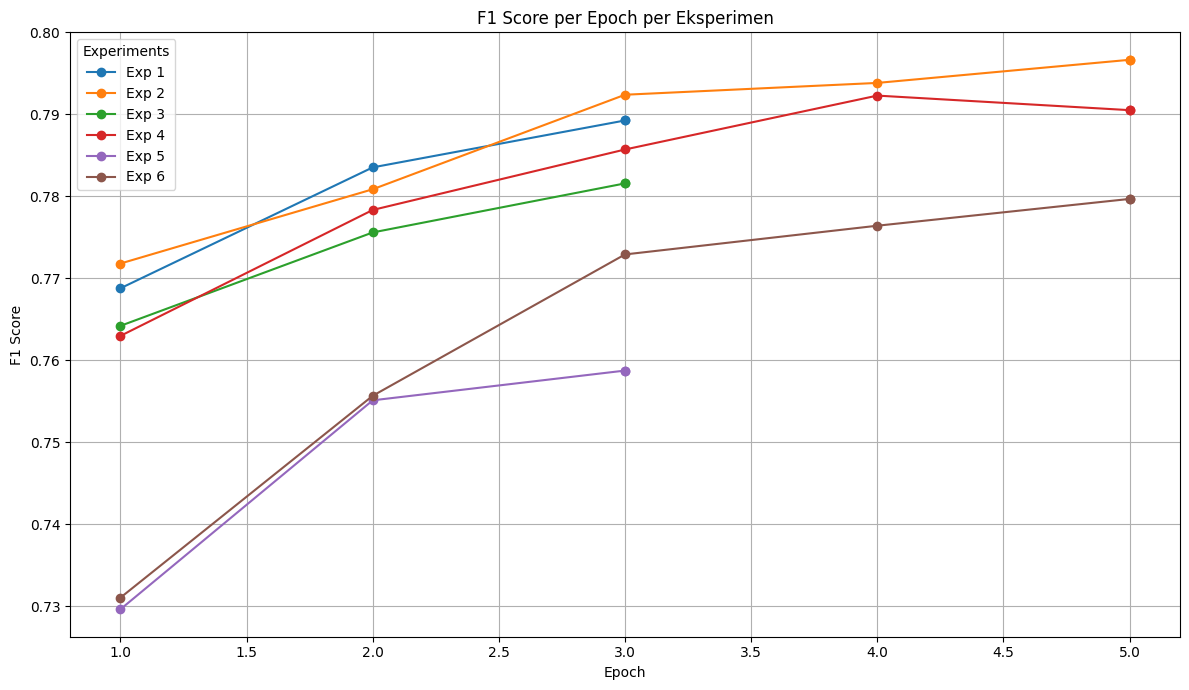

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Loop setiap experiment
for exp_id in df_epochs["experiment"].unique():
    df_exp = df_epochs[df_epochs["experiment"] == exp_id]
    label = f"Exp {exp_id}"
    plt.plot(df_exp["epoch"], df_exp["f1"], marker="o", label=label)

plt.title("F1 Score per Epoch per Eksperimen")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.grid(True)
plt.legend(title="Experiments")
plt.tight_layout()
plt.show()

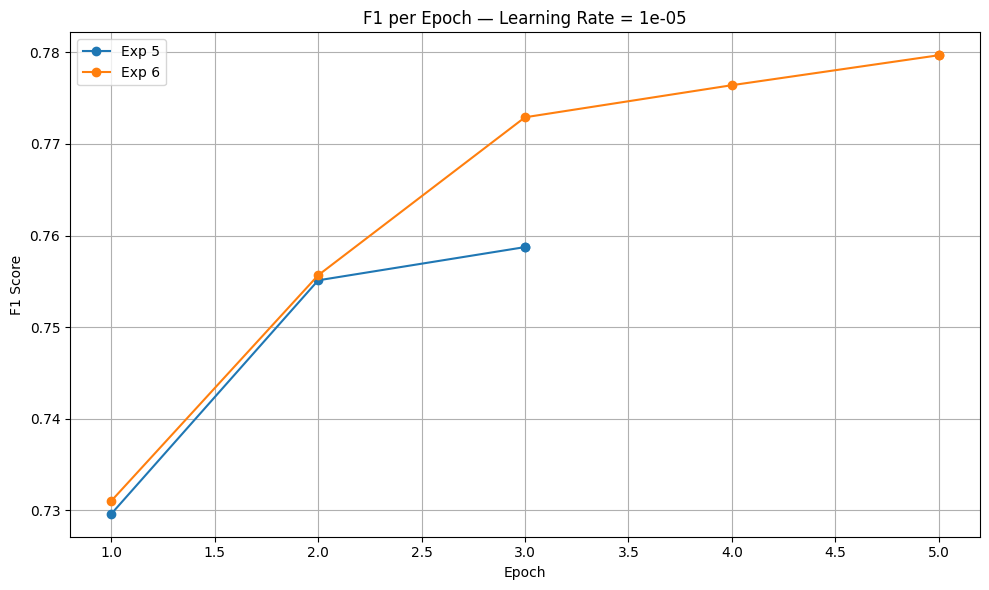

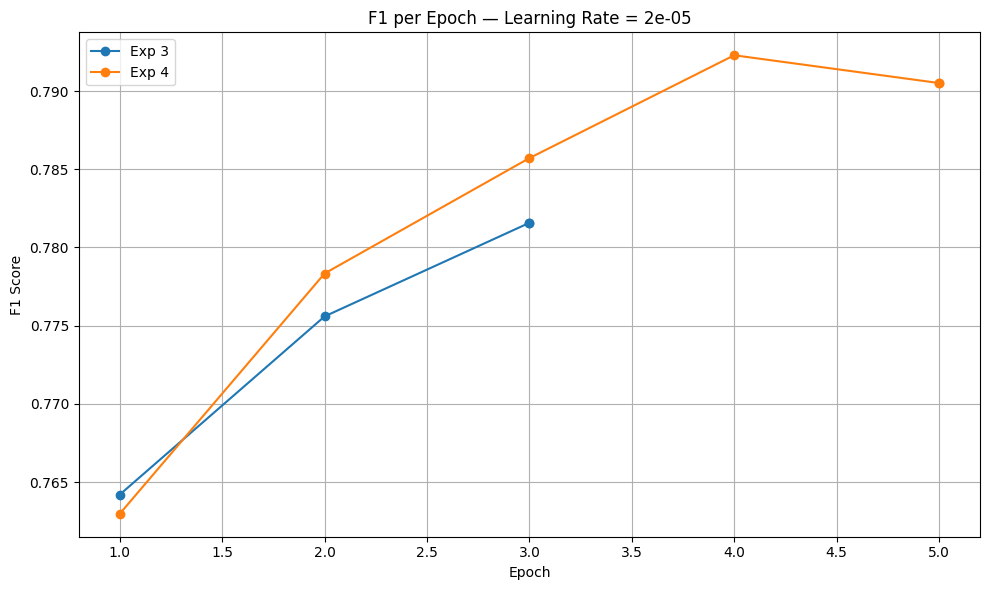

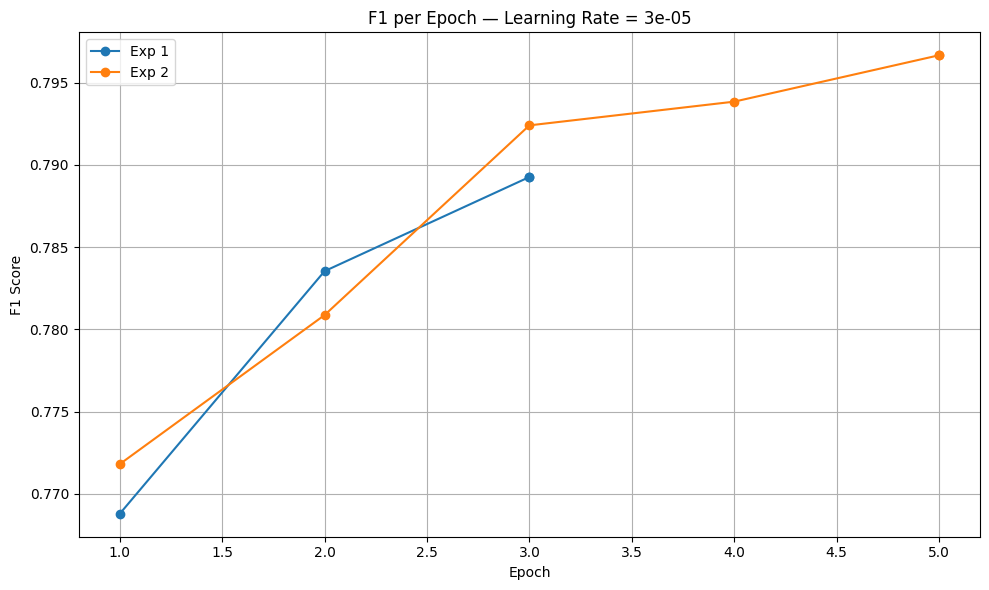

In [34]:
import matplotlib.pyplot as plt

learning_rates = sorted(df_plot["learning_rate"].unique())

for lr in learning_rates:
    df_lr = df_plot[df_plot["learning_rate"] == lr]
    unique_exps = df_lr["experiment"].unique()

    plt.figure(figsize=(10, 6))

    for exp in unique_exps:
        df_exp = df_lr[df_lr["experiment"] == exp]
        plt.plot(df_exp["epoch"], df_exp["f1"], marker="o", label=f"Exp {exp}")

    plt.title(f"F1 per Epoch — Learning Rate = {lr}")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

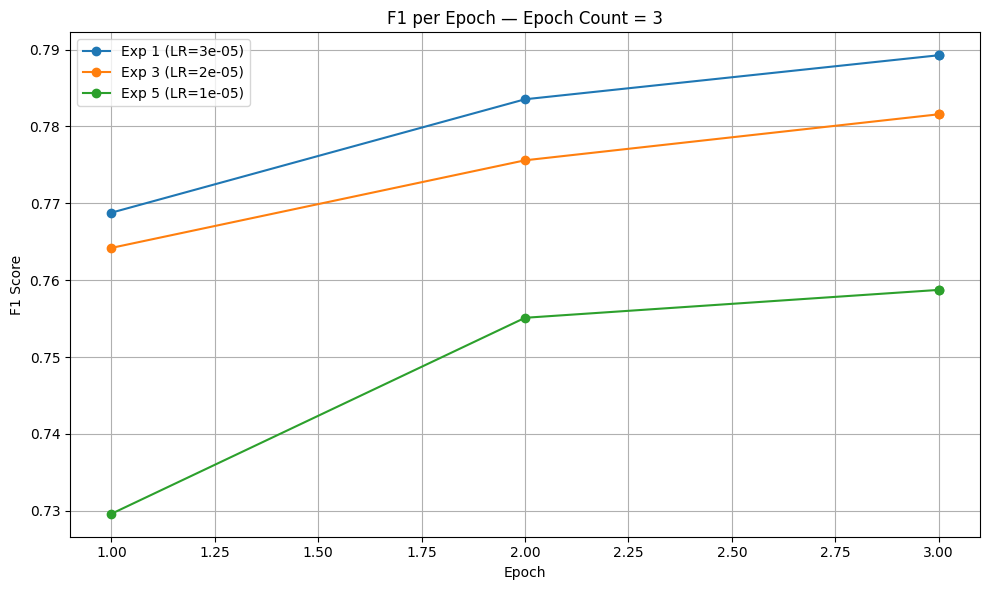

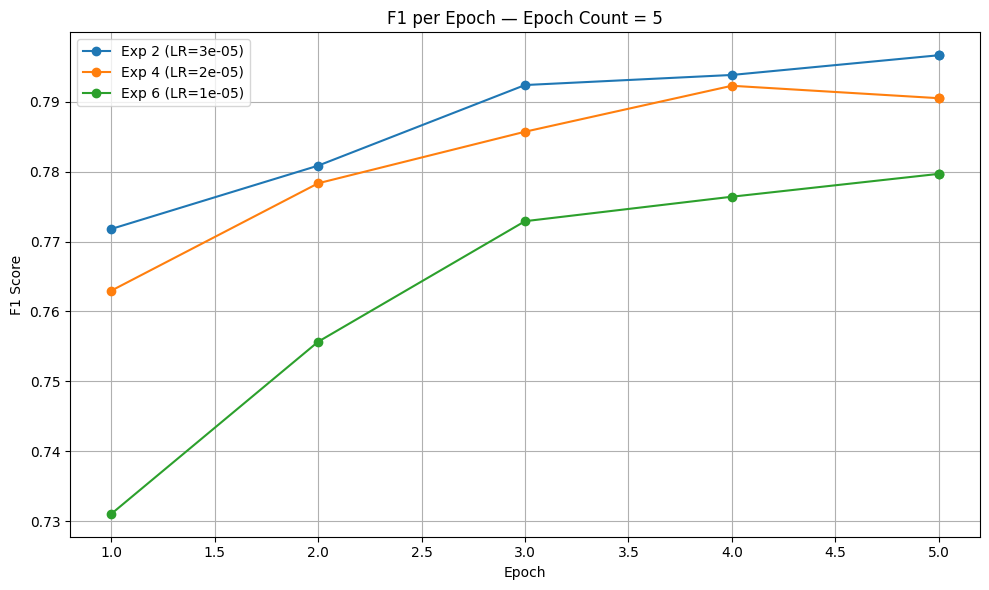

In [35]:
epoch_counts = sorted(df_plot["epochs"].unique())

for epc in epoch_counts:
    df_ep = df_plot[df_plot["epochs"] == epc]
    unique_exps = df_ep["experiment"].unique()

    plt.figure(figsize=(10, 6))

    for exp in unique_exps:
        df_exp = df_ep[df_ep["experiment"] == exp]
        lr = df_exp["learning_rate"].iloc[0]
        plt.plot(df_exp["epoch"], df_exp["f1"], marker="o",
                 label=f"Exp {exp} (LR={lr})")

    plt.title(f"F1 per Epoch — Epoch Count = {epc}")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

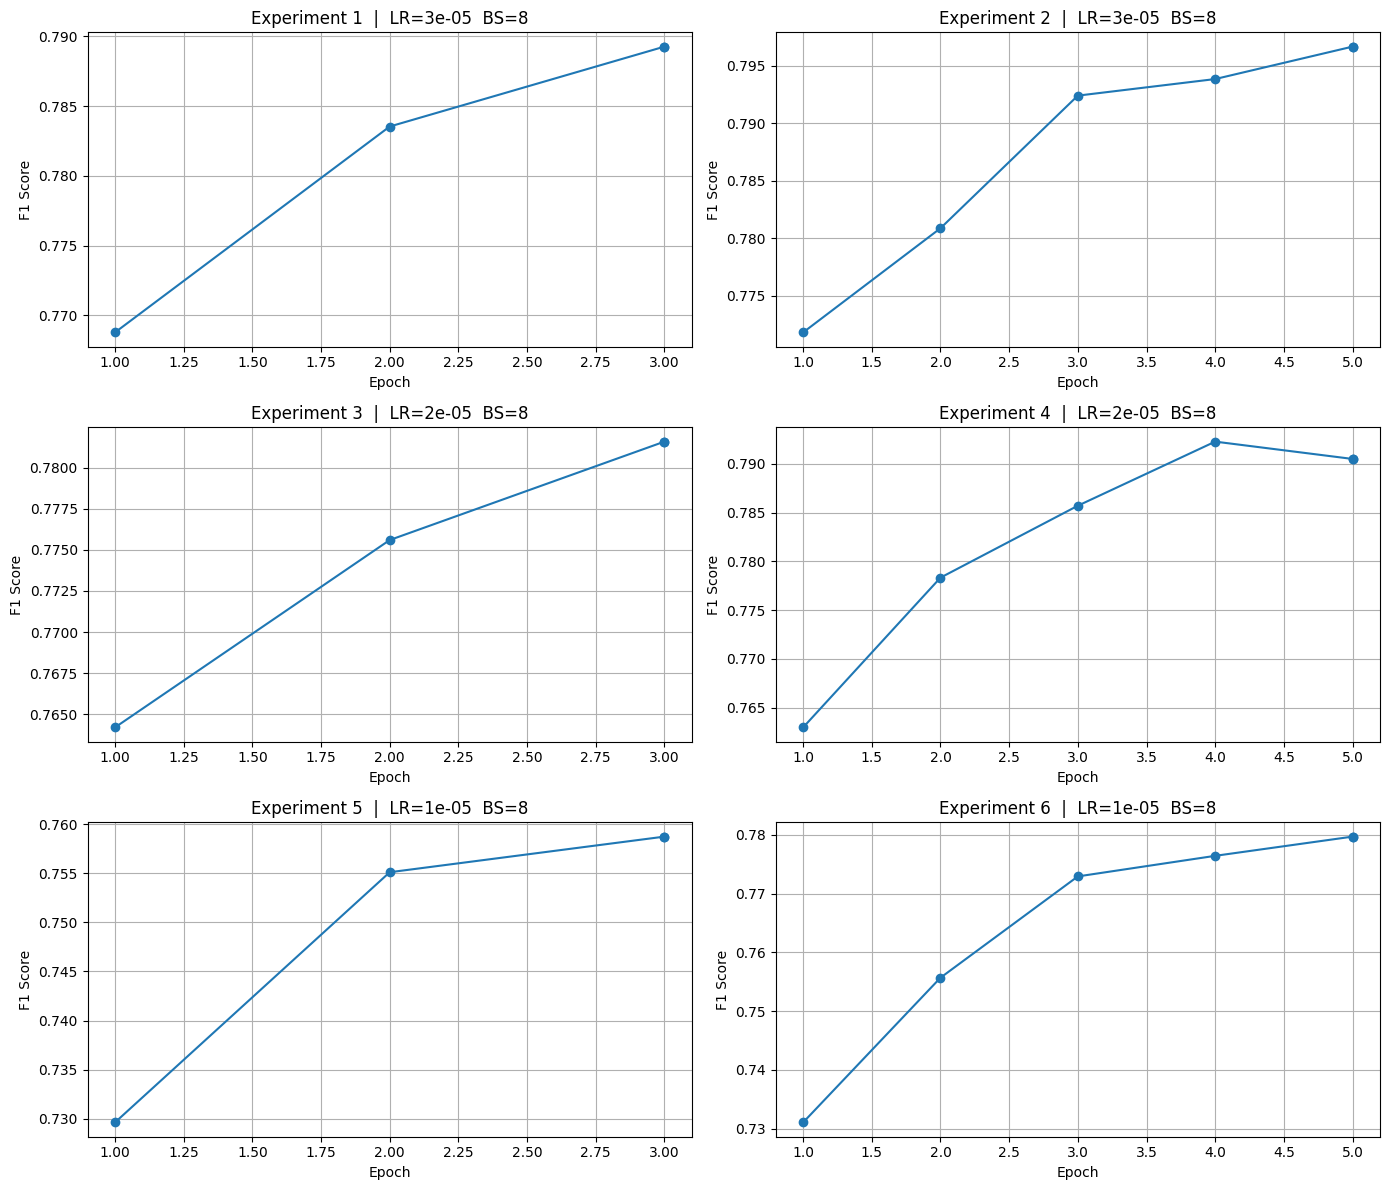

In [36]:
import math

unique_exps = df_plot["experiment"].unique()

cols = 2
rows = math.ceil(len(unique_exps) / cols)

plt.figure(figsize=(14, rows * 4))

for i, exp in enumerate(unique_exps, 1):
    df_exp = df_plot[df_plot["experiment"] == exp]

    plt.subplot(rows, cols, i)
    plt.plot(df_exp["epoch"], df_exp["f1"], marker="o")

    lr = df_exp["learning_rate"].iloc[0]
    bs = df_exp["batch_size"].iloc[0]

    plt.title(f"Experiment {exp}  |  LR={lr}  BS={bs}")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.grid(True)

plt.tight_layout()
plt.show()

In [37]:
import plotly.express as px

fig = px.line(
    df_plot,
    x="epoch",
    y="f1",
    color="experiment",
    line_group="experiment",
    hover_data=["learning_rate", "batch_size"],
    markers=True,
    title="Interactive F1 Score per Epoch per Experiment"
)

fig.show()

# **6 - Analisis Model Terbaik**
* Muat model
* Lihat label yang digunakan
* Lihat jumlah parameter
* Prediksi input langsung beserta label

In [38]:
from transformers import BertForTokenClassification, BertTokenizerFast

model = BertForTokenClassification.from_pretrained(best_model_path)
tokenizer = BertTokenizerFast.from_pretrained(best_model_path)

print("Model terbaik berhasil dimuat!")
print("Jumlah label:", model.num_labels)

Model terbaik berhasil dimuat!
Jumlah label: 7


In [39]:
print("ID → Label:", model.config.id2label)
print("Label → ID:", model.config.label2id)

ID → Label: {0: 'B-HSkill', 1: 'B-SSkill', 2: 'B-Tech', 3: 'I-HSkill', 4: 'I-SSkill', 5: 'I-Tech', 6: 'O'}
Label → ID: {'B-HSkill': 0, 'B-SSkill': 1, 'B-Tech': 2, 'I-HSkill': 3, 'I-SSkill': 4, 'I-Tech': 5, 'O': 6}


In [40]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameter:", total_params)
print("Trainable parameter:", trainable_params)

Total parameter: 109972999
Trainable parameter: 109972999


In [41]:
example_text = "Menguasai Javascript dan Python serta memahami konsep OOP."

tokens = tokenizer(example_text.split(),
                   is_split_into_words=True,
                   return_tensors="pt")

outputs = model(**tokens)
pred_ids = outputs.logits.argmax(dim=-1)[0].tolist()

for tok_id, pred in zip(tokens.input_ids[0], pred_ids):
    print(tokenizer.decode([tok_id]), "→", model.config.id2label[pred])

[CLS] → O
menguasai → O
javascript → B-Tech
dan → O
pyth → B-Tech
##on → B-Tech
serta → O
memahami → O
konsep → O
oo → B-HSkill
##p → B-HSkill
. → O
[SEP] → O


# **7 - Evaluasi Model Terbaik di Test Set**
* Tokenisasi dan align dataset kembali
* Muat dataset kembali
* Muat trainer dengan model terbaik  yang disimpan
* Tes Metrik
* Confusion Matrix Normalize (Rasio Kesalahan)
* Confusion Matrix Raw Count (Hitung Jumlah Salah/Benar)


In [42]:
test_dataset = tokenized_datasets["test"]
test_dataset

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 431
})

In [43]:
def tokenize_and_align_labels(batch):
    tokenized = tokenizer(
        batch["tokens"],
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=256,
    )

    all_labels = batch["label_ids"]
    new_labels = []

    for i, labels in enumerate(all_labels):
        word_ids = tokenized.word_ids(batch_index=i)
        aligned_labels = []
        previous_word = None

        for word_id in word_ids:
            if word_id is None:
                aligned_labels.append(-100)
            elif word_id != previous_word:
                aligned_labels.append(labels[word_id])
            else:
                aligned_labels.append(labels[word_id])
            previous_word = word_id

        new_labels.append(aligned_labels)

    tokenized["labels"] = new_labels
    return tokenized

In [44]:
from datasets import load_dataset

test_data = load_dataset("json", data_files="/content/test.json")
tokenized_test = test_data.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=test_data["train"].column_names
)

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/431 [00:00<?, ? examples/s]

In [45]:
from transformers import Trainer

trainer_test = Trainer(
    model=model,                 # model terbaik yg tadi sudah diload
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

/tmp/ipython-input-1457199283.py:3: FutureWarning:

`tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [46]:
test_metrics = trainer_test.evaluate(tokenized_test["train"])
test_metrics

{'eval_loss': 0.2085203379392624,
 'eval_model_preparation_time': 0.0035,
 'eval_precision': 0.7671542553191489,
 'eval_recall': 0.802699318213441,
 'eval_f1': 0.7845243761474127,
 'eval_accuracy': 0.9300567495031857,
 'eval_runtime': 6.3711,
 'eval_samples_per_second': 67.649,
 'eval_steps_per_second': 8.476}

In [47]:
import numpy as np

predictions_output = trainer_test.predict(tokenized_test["train"])
pred_logits = predictions_output.predictions
true_label_ids = predictions_output.label_ids

# Ambil prediksi argmax
pred_ids = np.argmax(pred_logits, axis=2)

In [48]:
true_labels = []
pred_labels = []

for pred_seq, label_seq in zip(pred_ids, true_label_ids):
    for p, l in zip(pred_seq, label_seq):
        if l != -100:
            true_labels.append(l)
            pred_labels.append(p)

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels_sorted = list(id2label.keys())

cm = confusion_matrix(true_labels, pred_labels, labels=labels_sorted)

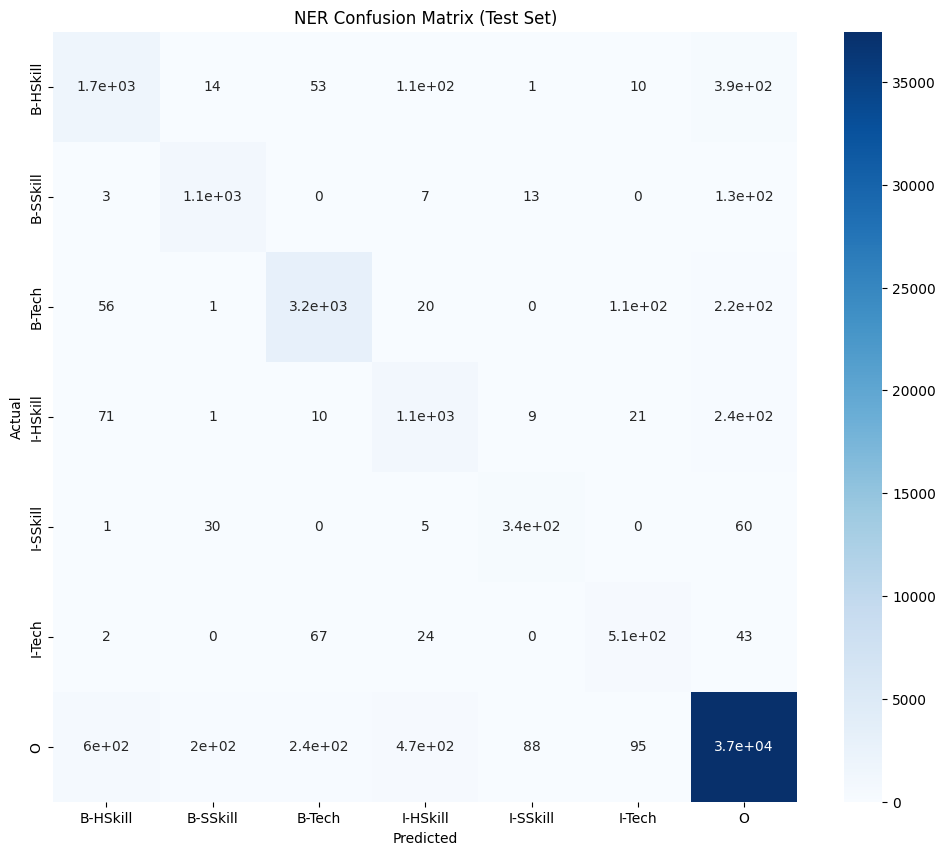

In [50]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    xticklabels=[id2label[i] for i in labels_sorted],
    yticklabels=[id2label[i] for i in labels_sorted]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("NER Confusion Matrix (Test Set)")
plt.show()

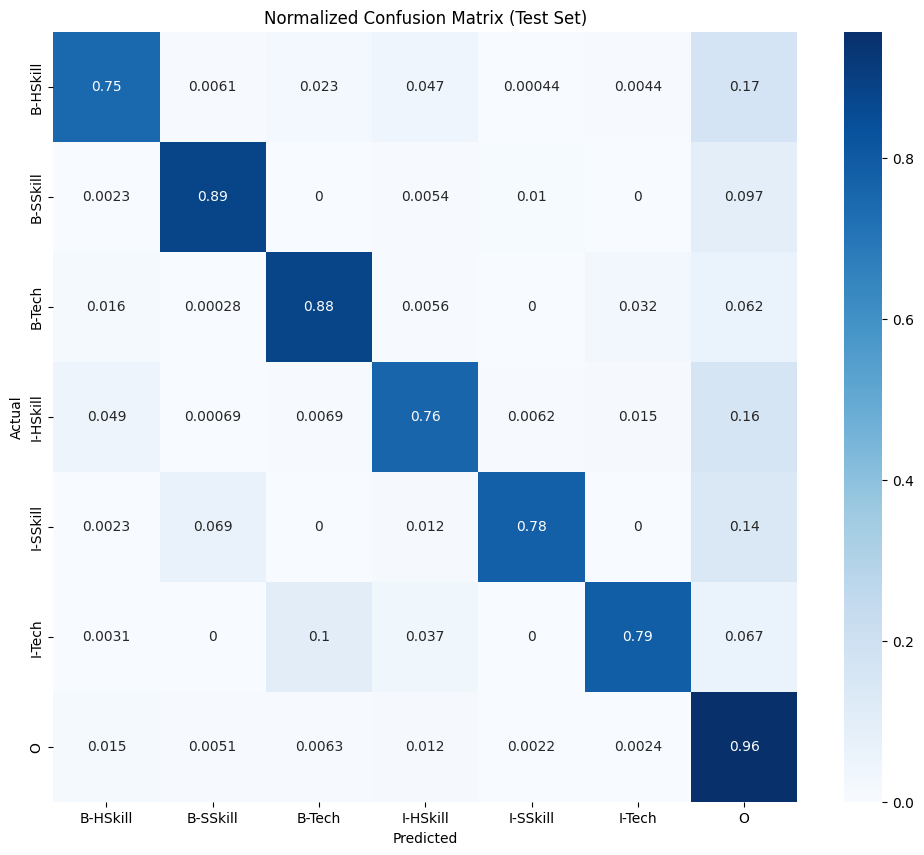

In [51]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, None]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_normalized,
    annot=True,
    cmap="Blues",
    xticklabels=[id2label[i] for i in labels_sorted],
    yticklabels=[id2label[i] for i in labels_sorted]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Normalized Confusion Matrix (Test Set)")
plt.show()

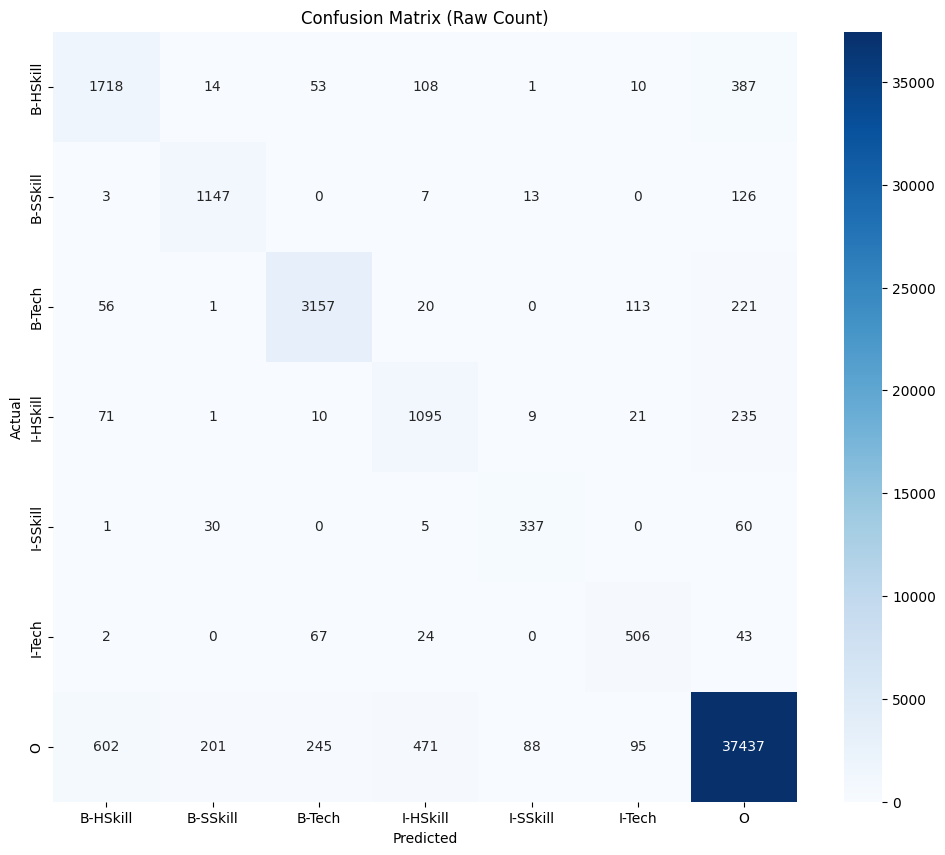

In [52]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,               # ⬅ raw count
    annot=True,       # tampilkan angka
    fmt="d",          # format integer
    cmap="Blues",
    xticklabels=[id2label[i] for i in labels_sorted],
    yticklabels=[id2label[i] for i in labels_sorted]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Raw Count)")
plt.show()

In [53]:
def ner_classification_report(model, dataset_tokenized):
    preds, labels, _ = trainer_test.predict(dataset_tokenized)

    preds = np.argmax(preds, axis=2)

    true_labels = []
    pred_labels = []

    for pred_row, label_row in zip(preds, labels):
        true = []
        pred = []
        for p, l in zip(pred_row, label_row):
            if l == -100:
                continue
            true.append(id2label[l])
            pred.append(id2label[p])
        true_labels.append(true)
        pred_labels.append(pred)

    print(classification_report(true_labels, pred_labels))

# **8 - Test Kalimat Asli (Inferensi)**

In [55]:
import torch

def ner_inference(text):
    """
    Input: text (string)
    Output: list of (word, label) pairs
    """
    device = next(model.parameters()).device  # CPU atau cuda

    # tokenisasi (kembalian: BatchEncoding)
    # gunakan is_split_into_words=True karena kita akan feed oleh kata
    tokens = text.split()
    encoded = tokenizer(
        tokens,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )

    # ambil word_ids (fungsi BatchEncoding) SEBELUM kita ubah encoded -> dict
    word_ids = encoded.word_ids(batch_index=0)  # list, berisi None untuk special tokens

    # pindahkan tensor ke device model (tetap simpan sebagai dict untuk model(**...))
    inputs = {k: v.to(device) for k, v in encoded.items()}

    # forward
    with torch.no_grad():
        outputs = model(**inputs)

    pred_ids = outputs.logits.argmax(dim=-1)[0].tolist()

    # gabungkan prediksi ke word asli (abaikan subwords & special tokens)
    final_tokens = []
    final_labels = []
    prev_word_idx = None

    for pred, word_idx in zip(pred_ids, word_ids):
        if word_idx is None:
            continue
        if word_idx != prev_word_idx:
            final_tokens.append(tokens[word_idx])
            final_labels.append(model.config.id2label[pred])
        prev_word_idx = word_idx

    return list(zip(final_tokens, final_labels))

In [56]:
sentence = "Menguasai Python, Java dan memahami konsep REST API."
result = ner_inference(sentence)

for tok, label in result:
    print(f"{tok:15} → {label}")

Menguasai       → O
Python,         → B-Tech
Java            → B-Tech
dan             → O
memahami        → O
konsep          → O
REST            → B-Tech
API.            → I-Tech


# **9 - Analisis Mendalam**
* Analisis kesalahan
* Contoh kesalahan
* Classification report



In [81]:
def collect_errors(model, raw_ds, tokenized_ds, max_errors=30):
    """
    raw_ds       = dataset mentah (berisi tokens & labels)
    tokenized_ds = dataset tokenized (untuk prediksi model)
    """

    trainer_eval = Trainer(
        model=model,
        tokenizer=tokenizer,
        data_collator=data_collator
    )

    # Prediksi menggunakan dataset tokenized
    outputs = trainer_eval.predict(tokenized_ds)
    preds = np.argmax(outputs.predictions, axis=2)
    labels = outputs.label_ids

    errors = []

    for i in range(len(raw_ds)):
        tokens = raw_ds[i]["tokens"]
        true_label_ids = raw_ds[i]["label_ids"]

        # 🔥 RE-TOKENIZE supaya kita dapat word_ids()
        encoded = tokenizer(
            tokens,
            is_split_into_words=True,
            return_offsets_mapping=True,
            truncation=True,
            padding=False
        )

        word_ids = encoded.word_ids()

        pred_row = preds[i]
        label_row = labels[i]

        aligned_true = []
        aligned_pred = []

        last_word = -1
        for wid, p, l in zip(word_ids, pred_row, label_row):
            if wid is None or l == -100:
                continue
            if wid != last_word:
                aligned_true.append(id2label[l])
                aligned_pred.append(id2label[p])
                last_word = wid

        # Deteksi error
        if aligned_true != aligned_pred:
            errors.append({
                "sentence_id": i,
                "tokens": tokens,
                "true_labels": aligned_true,
                "pred_labels": aligned_pred
            })

        if len(errors) >= max_errors:
            break

    return pd.DataFrame(errors)

In [82]:
from transformers import DataCollatorForTokenClassification
data_collator = DataCollatorForTokenClassification(tokenizer)

In [83]:
import json
from datasets import Dataset

with open("/content/test.json", "r") as f:
    raw_test_list = json.load(f)

raw_test_dataset = Dataset.from_list(raw_test_list)

In [84]:
tokenized_test_dataset = tokenized_datasets["test"]
tokenized_test_dataset

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 431
})

In [85]:
df_errors = collect_errors(
    model,
    raw_test_dataset,
    tokenized_test_dataset
)

df_errors.head()

/tmp/ipython-input-2145491530.py:7: FutureWarning:

`tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


,sentence_id,tokens,true_labels,pred_labels
0,0,"[PT, KSK, Insurance, Indonesia, -, Jakarta, .,...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
1,1,"[Company, Confidential, Jakarta, Pusat, ., Dib...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
2,2,"[Deskripsi, Pekerjaan, Membuat, laporan, proye...","[O, O, O, B-HSkill, I-HSkill, O, B-HSkill, I-H...","[O, O, B-HSkill, I-HSkill, I-HSkill, O, B-HSki..."
3,4,"[Deskripsi, Pekerjaan, Menentukan, strategi, ,...","[O, O, O, O, O, O, O, O, O, O, O, O, O, B-HSki...","[O, O, O, O, O, O, O, O, O, O, O, O, O, B-HSki..."
4,5,"[PT, ., Asian, Sigma, Technology, ., Surabaya,...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."


In [86]:
from termcolor import colored

def show_error(idx):
    row = df_errors.iloc[idx]
    toks = row["tokens"]
    true = row["true_labels"]
    pred = row["pred_labels"]

    print("\n--- ERROR SAMPLE ---\n")

    for token, t, p in zip(toks, true, pred):
        if t == p:
            print(f"{token:15} ({t})")
        else:
            print(colored(f"{token:15}", "red"), f"(true={t}, pred={p})")

In [87]:
show_error(0)


--- ERROR SAMPLE ---

PT              (O)
KSK             (O)
Insurance       (O)
Indonesia       (O)
-               (O)
Jakarta         (O)
.               (O)
IT              (O)
Application     (O)
&               (O)
Reporting       (O)
Support         (O)
,               (O)
Persyaratan     (O)
S1              (O)
di              (O)
bidang          (O)
IT              (O)
2               (O)
tahun           (O)
pengalaman      (O)
dalam           (O)
aplikasi        (B-HSkill)
dan             (O)
pelaporan       (B-HSkill)
TI              (I-HSkill)
Maju            (O)
di              (O)
Ms.             (B-Tech)
SQL             (true=I-Tech, pred=B-Tech)
Query           (I-Tech)
Pengalaman      (O)
menggunakan     (O)
Crystal         (B-Tech)
Report          (I-Tech)
Memiliki        (O)
pengetahuan     (O)
tentang         (O)
.Net            (B-Tech)
(               (O)
C#              (B-Tech)
)               (O)
Memiliki        (O)
pengetahuan     (O)
tentang         (O)
sis

In [89]:
def get_true_pred_labels(model, raw_ds, tokenized_ds):
    trainer_eval = Trainer(
        model=model,
        tokenizer=tokenizer,
        data_collator=data_collator
    )

    outputs = trainer_eval.predict(tokenized_ds)

    preds = np.argmax(outputs.predictions, axis=2)
    gold = outputs.label_ids

    all_true = []
    all_pred = []

    for i in range(len(raw_ds)):
        tokens = raw_ds[i]["tokens"]

        # Tokenize ulang untuk mengambil word_ids()
        encoded = tokenizer(
            tokens,
            is_split_into_words=True,
            return_offsets_mapping=True,
            truncation=True,
            padding=False
        )
        word_ids = encoded.word_ids()

        pred_row = preds[i]
        label_row = gold[i]

        aligned_true = []
        aligned_pred = []

        last = -1
        for wid, p, l in zip(word_ids, pred_row, label_row):
            if wid is None or l == -100:
                continue
            if wid != last:
                aligned_true.append(id2label[l])
                aligned_pred.append(id2label[p])
                last = wid

        all_true.append(aligned_true)
        all_pred.append(aligned_pred)

    return all_true, all_pred

In [90]:
from seqeval.metrics import classification_report as seq_classification_report

true_labels, pred_labels = get_true_pred_labels(
    model,
    raw_test_dataset,
    tokenized_test_dataset
)

print(seq_classification_report(true_labels, pred_labels))


/tmp/ipython-input-4239734736.py:2: FutureWarning:

`tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


              precision    recall  f1-score   support

      HSkill       0.60      0.67      0.64      1660
      SSkill       0.79      0.85      0.82      1116
        Tech       0.83      0.86      0.85      1831

   micro avg       0.73      0.79      0.76      4607
   macro avg       0.74      0.80      0.77      4607
weighted avg       0.74      0.79      0.76      4607



In [93]:
test_dataset = tokenized_datasets["test"]
test_dataset

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 431
})

In [96]:
type(test_dataset), len(test_dataset), test_dataset[0]

(datasets.arrow_dataset.Dataset,
 431,
 {'labels': [-100,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   0,
   6,
   0,
   3,
   6,
   6,
   2,
   2,
   5,
   5,
   5,
   5,
   6,
   6,
   2,
   5,
   6,
   6,
   6,
   2,
   2,
   6,
   2,
   2,
   6,
   6,
   6,
   6,
   0,
   3,
   6,
   0,
   3,
   6,
   6,
   6,
   1,
   4,
   6,
   6,
   6,
   6,
   1,
   4,
   6,
   6,
   6,
   6,
   6,
   6,
   1,
   6,
   6,
   1,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   6,
   -100],
  'input_ids': [3,
   2865,
   9314,
   942,
   2421,
   26244,
   1718,
   17,
   1892,
   18,
   2848,
   31145,
   10,
   16840,
   1518,
   16

In [97]:
from collections import Counter
from tqdm import tqdm
import torch

def error_breakdown_per_label(model, tokenized_test, id2label):
    model.eval()

    correct = Counter()
    incorrect = Counter()
    confusions = Counter()

    for i in tqdm(range(len(tokenized_test))):

        item = tokenized_test[i]

        input_ids = torch.tensor([item["input_ids"]]).to(model.device)
        attn = torch.tensor([item["attention_mask"]]).to(model.device)

        with torch.no_grad():
            logits = model(input_ids, attention_mask=attn).logits

        pred_ids = logits.argmax(dim=-1)[0].cpu().tolist()
        true_ids = item["labels"]
        mask = item["attention_mask"]

        for t_id, p_id, m in zip(true_ids, pred_ids, mask):

            if m == 0:
                continue  # skip padding
            if t_id == -100:
                continue  # skip special tokens (CLS/SEP/subword align)

            true_label = id2label[t_id]
            pred_label = id2label[p_id]

            if t_id == p_id:
                correct[true_label] += 1
            else:
                incorrect[true_label] += 1
                confusions[(true_label, pred_label)] += 1

    return {
        "correct": correct,
        "incorrect": incorrect,
        "confusions": confusions
    }

# Panggil
id2label = model.config.id2label
breakdown = error_breakdown_per_label(model, test_dataset, id2label)

breakdown

100%|██████████| 431/431 [00:12<00:00, 34.16it/s]


{'correct': Counter({'O': 37437,
          'B-HSkill': 1718,
          'I-HSkill': 1095,
          'B-Tech': 3157,
          'I-Tech': 506,
          'B-SSkill': 1147,
          'I-SSkill': 337}),
 'incorrect': Counter({'I-Tech': 136,
          'B-Tech': 411,
          'B-HSkill': 573,
          'I-HSkill': 347,
          'B-SSkill': 149,
          'O': 1702,
          'I-SSkill': 96}),
 'confusions': Counter({('I-Tech', 'B-Tech'): 67,
          ('B-Tech', 'I-Tech'): 113,
          ('B-HSkill', 'O'): 387,
          ('I-HSkill', 'O'): 235,
          ('B-SSkill', 'O'): 126,
          ('O', 'B-HSkill'): 602,
          ('O', 'I-HSkill'): 471,
          ('I-Tech', 'O'): 43,
          ('I-HSkill', 'B-HSkill'): 71,
          ('B-HSkill', 'I-HSkill'): 108,
          ('O', 'B-SSkill'): 201,
          ('O', 'I-SSkill'): 88,
          ('I-SSkill', 'B-SSkill'): 30,
          ('I-SSkill', 'O'): 60,
          ('O', 'I-Tech'): 95,
          ('B-Tech', 'O'): 221,
          ('B-Tech', 'B-HSkill'): 56,


In [98]:
import pandas as pd

rows = []
for label in id2label.values():
    c = breakdown["correct"][label]
    w = breakdown["incorrect"][label]
    total = c + w
    acc = c / total if total > 0 else 0

    rows.append({
        "Label": label,
        "Benar": c,
        "Salah": w,
        "Total": total,
        "Akurasi (%)": round(acc * 100, 2)
    })

df_breakdown = pd.DataFrame(rows)
df_breakdown

,Label,Benar,Salah,Total,Akurasi (%)
0,B-HSkill,1718,573,2291,74.99
1,B-SSkill,1147,149,1296,88.50
2,B-Tech,3157,411,3568,88.48
3,I-HSkill,1095,347,1442,75.94
4,I-SSkill,337,96,433,77.83
5,I-Tech,506,136,642,78.82
6,O,37437,1702,39139,95.65


In [99]:
df_confuse = pd.DataFrame([
    {"True": t, "Predicted": p, "Count": n}
    for (t, p), n in breakdown["confusions"].items()
])

df_confuse.sort_values("Count", ascending=False).head(20)

,True,Predicted,Count
5,O,B-HSkill,602
6,O,I-HSkill,471
2,B-HSkill,O,387
17,O,B-Tech,245
3,I-HSkill,O,235
15,B-Tech,O,221
10,O,B-SSkill,201
4,B-SSkill,O,126
1,B-Tech,I-Tech,113
9,B-HSkill,I-HSkill,108


In [100]:
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

def collect_confidences(model, test_dataset):
    model.eval()
    correct_conf = []
    incorrect_conf = []

    for i in tqdm(range(len(test_dataset))):
        item = test_dataset[i]

        input_ids = torch.tensor([item["input_ids"]]).to(model.device)
        attn = torch.tensor([item["attention_mask"]]).to(model.device)

        with torch.no_grad():
            logits = model(input_ids, attention_mask=attn).logits
            probs = logits.softmax(dim=-1)[0].cpu().numpy()

        preds = probs.argmax(axis=-1)
        trues = item["labels"]

        for true, pred, prob_vec, mask in zip(trues, preds, probs, item["attention_mask"]):
            if mask == 0:
                continue
            conf = prob_vec[pred]
            if true == pred:
                correct_conf.append(conf)
            else:
                incorrect_conf.append(conf)

    return correct_conf, incorrect_conf

correct_conf, incorrect_conf = collect_confidences(model, test_dataset)

100%|██████████| 431/431 [00:13<00:00, 32.33it/s]


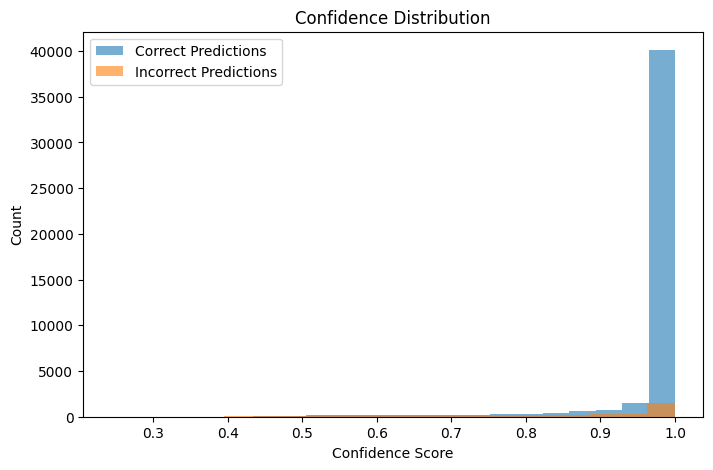

In [101]:
plt.figure(figsize=(8,5))
plt.hist(correct_conf, bins=20, alpha=0.6, label="Correct Predictions")
plt.hist(incorrect_conf, bins=20, alpha=0.6, label="Incorrect Predictions")
plt.title("Confidence Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Count")
plt.legend()
plt.show()

In [106]:
df_errors_label = df_breakdown.copy()
df_errors_label["Error Rate"] = df_errors_label["Salah"] / df_errors_label["Total"]

df_errors_label

,Label,Benar,Salah,Total,Akurasi (%),Error Rate
0,B-HSkill,1718,573,2291,74.99,0.250109
1,B-SSkill,1147,149,1296,88.50,0.114969
2,B-Tech,3157,411,3568,88.48,0.115191
3,I-HSkill,1095,347,1442,75.94,0.240638
4,I-SSkill,337,96,433,77.83,0.221709
5,I-Tech,506,136,642,78.82,0.211838
6,O,37437,1702,39139,95.65,0.043486


In [107]:
df_difficulty = pd.DataFrame({
    "Label": df_errors_label["Label"],
    "DifficultyScore": df_errors_label["Error Rate"]
}).sort_values("DifficultyScore", ascending=False)

df_difficulty

,Label,DifficultyScore
0,B-HSkill,0.250109
3,I-HSkill,0.240638
4,I-SSkill,0.221709
5,I-Tech,0.211838
2,B-Tech,0.115191
1,B-SSkill,0.114969
6,O,0.043486


In [114]:
from IPython.display import HTML, display
import torch

def highlight_ner(text):
    # Tokenize + ambil offset mapping
    encoded = tokenizer(text, return_offsets_mapping=True, return_tensors="pt")
    offsets = encoded["offset_mapping"][0].tolist()

    # Buat salinan input tanpa offset_mapping
    model_inputs = {k: v.to(model.device) for k, v in encoded.items() if k != "offset_mapping"}

    # Model inference
    with torch.no_grad():
        logits = model(**model_inputs).logits

    preds = logits.argmax(dim=-1)[0].cpu().tolist()
    label_map = model.config.id2label

    html = ""
    for (start, end), pred_id in zip(offsets, preds):
        if start == end:
            continue  # skip empty offsets

        token = text[start:end]
        label = label_map[pred_id]

        # Remove B- and I-
        base_label = label.replace("B-","").replace("I-","")

        color = {
            "HSkill": "#6fd36f",
            "SSkill": "#ffd86e",
            "Tech": "#6fd0ff"
        }.get(base_label, None)

        if color:
            html += f"<span style='background-color:{color}; padding:2px; border-radius:3px'>{token}</span> "
        else:
            html += token + " "

    display(HTML(html))

In [115]:
highlight_ner("Menguasai Python, Java dan memahami konsep REST API serta kemampuan komunikasi yang baik.")